In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
asjg;las;l

In [2]:
df = pd.read_csv('AI_Human.csv')
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [3]:
df.rename(columns={'text':'Text','generated':'Label'},inplace=True)
df.head()

,Text,Label
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Text    487235 non-null  object 
 1   Label   487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [5]:
df.shape

(487235, 2)

In [6]:
df = df.dropna()
df.reset_index(drop=True)
df.shape

(487235, 2)

In [7]:
df = df.groupby(['Label']).apply(lambda x: x.sample(25000)).reset_index(drop=True)
df.shape

(50000, 2)

In [8]:
df['Text'] = df['Text'].apply(lambda x: x.lower())
df.head()

,Text,Label
0,toe laws have changed. we now have days were w...,0.0
1,driverless cars may be modern and use half of ...,0.0
2,dear mrs. principal\n\ni don't think its right...,0.0
3,"deal principal,\n\nstudents like to have cell ...",0.0
4,imagine that someone ii your life gave advice ...,0.0


In [9]:
df = df.astype({'Label':int})
df.head()

,Text,Label
0,toe laws have changed. we now have days were w...,0
1,driverless cars may be modern and use half of ...,0
2,dear mrs. principal\n\ni don't think its right...,0
3,"deal principal,\n\nstudents like to have cell ...",0
4,imagine that someone ii your life gave advice ...,0


In [10]:
df['Text'] = df['Text'].str.replace(r"\b\w*\d\w*\b", "", regex=True)
df['Text'] = df['Text'].str.replace("[^a-zA-Z]", " ", regex=True)
df['Text'] = df['Text'].str.strip().str.replace(r'\s+', ' ', regex=True)
df.head()

,Text,Label
0,toe laws have changed we now have days were we...,0
1,driverless cars may be modern and use half of ...,0
2,dear mrs principal i don t think its right tha...,0
3,deal principal students like to have cell phon...,0
4,imagine that someone ii your life gave advice ...,0


In [11]:
df['Text'] = df['Text'].apply(lambda x: x.split())
df.head()

,Text,Label
0,"[toe, laws, have, changed, we, now, have, days...",0
1,"[driverless, cars, may, be, modern, and, use, ...",0
2,"[dear, mrs, principal, i, don, t, think, its, ...",0
3,"[deal, principal, students, like, to, have, ce...",0
4,"[imagine, that, someone, ii, your, life, gave,...",0


In [12]:
wordsEnglish = stopwords.words('English')
wordsEnglish

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [13]:
df['Text'] = df['Text'].apply(lambda x: [item for item in x if item not in wordsEnglish])
df['Text']

0        [toe, laws, changed, days, cannot, use, cars, ...
1        [driverless, cars, may, modern, use, half, tod...
2        [dear, mrs, principal, think, right, changing,...
3        [deal, principal, students, like, cell, phones...
4        [imagine, someone, ii, life, gave, advice, aiw...
                               ...                        
49995    [high, goals, essential, life, help, lead, suc...
49996    [hey, essay, gonna, talk, technology, communic...
49997    [facial, action, coding, system, facs, method,...
49998    [dear, state, senator, writing, star, opinion,...
49999    [failure, inevitable, part, life, difficult, e...
Name: Text, Length: 50000, dtype: object

In [14]:
df['Text'] = df['Text'].apply(lambda x: list({item for item in x}))
df.head()

,Text,Label
0,"[culture, opportunities, states, walk, gas, sm...",0
1,"[embedding, states, cable, sensor, would, laws...",0
2,"[athletically, would, really, participate, go,...",0
3,"[often, would, simply, people, whenever, age, ...",0
4,"[enough, would, gave, really, people, friends,...",0


In [15]:
spell = SpellChecker()
results = set()
df['Text'].apply(results.update)
misspelled = spell.unknown(list(results))
misspelled

{'chosed',
 'baek',
 'arnt',
 'bornt',
 'nott',
 'sstaffa',
 'agurement',
 'maybeabilities',
 'dxesel',
 'bikeshdring',
 'hhomework',
 'algalgebrad',
 'cains',
 'rsassrch',
 'stright',
 'fifht',
 'nright',
 'zen',
 'tzmetime',
 'samuel',
 'pollutionqelated',
 'ztudentdesigned',
 'thaboutt',
 'soaboutzation',
 'zyoure',
 'irrisitable',
 'ie',
 'vkay',
 'actiknowac',
 'tdansdegional',
 'argueably',
 'tollenge',
 'teachercreated',
 'fcc',
 'dissoy',
 'thafromat',
 'pedestrianxriendly',
 'wendi',
 'srazy',
 'btbt',
 'hx',
 'whalwhat',
 'nestorian',
 'expertion',
 'bcientebtb',
 'extnacunniculanly',
 'bycycle',
 'clouddrkped',
 'pinterest',
 'teupt',
 'perpahps',
 'celfbelief',
 'unneuuary',
 'remputer',
 'comuter',
 'aedaedth',
 'automakes',
 'wnnnertakeall',
 'nonclass',
 'yebecausee',
 'mmateproblems',
 'unnatrual',
 'tetextand',
 'altiemetryfrom',
 'sometghing',
 'cultixate',
 'solvingills',
 'dhy',
 'snmetimes',
 'pqdcs',
 'pusuit',
 'refront',
 'cchangefirst',
 'olny',
 'makhng',
 'mi

In [16]:
df['Text'] = df['Text'].apply(lambda x: [item for item in x if item not in misspelled])
df['Text']

0        [culture, opportunities, states, walk, gas, sm...
1        [embedding, states, cable, sensor, would, laws...
2        [athletically, would, really, participate, go,...
3        [often, would, simply, people, whenever, age, ...
4        [enough, would, gave, really, people, friends,...
                               ...                        
49995    [growing, potential, avoid, people, binary, ke...
49996    [progress, feedback, people, able, come, techn...
49997    [psychology, raising, corner, specific, breaki...
49998    [heard, states, dear, give, would, mine, offic...
49999    [go, keep, mindset, resilience, difficult, com...
Name: Text, Length: 50000, dtype: object

In [17]:
lemmatizer = WordNetLemmatizer()
df['Text'] = df['Text'].apply(lambda x: [lemmatizer.lemmatize(word,pos='v') for word in x])
df.head()

,Text,Label
0,"[culture, opportunities, state, walk, gas, smo...",0
1,"[embed, state, cable, sensor, would, laws, sim...",0
2,"[athletically, would, really, participate, go,...",0
3,"[often, would, simply, people, whenever, age, ...",0
4,"[enough, would, give, really, people, friends,...",0


In [18]:
df['Text'] = df['Text'].apply(lambda x: [w for w in x if len(w)>2])
df.head()

,Text,Label
0,"[culture, opportunities, state, walk, gas, smo...",0
1,"[embed, state, cable, sensor, would, laws, sim...",0
2,"[athletically, would, really, participate, kee...",0
3,"[often, would, simply, people, whenever, age, ...",0
4,"[enough, would, give, really, people, friends,...",0


In [19]:
df['Text'] = df['Text'].apply(lambda x: " ".join(x))
df.head()

,Text,Label
0,culture opportunities state walk gas smog woul...,0
1,embed state cable sensor would laws simply dri...,0
2,athletically would really participate keep sit...,0
3,often would simply people whenever age choice ...,0
4,enough would give really people friends choice...,0


In [20]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
cv_fit = cv.fit_transform(df['Text'])
docs_df = pd.DataFrame(data=cv_fit.A,columns=cv.get_feature_names_out())
display(docs_df)

,aback,abandon,abandonment,abase,abate,abb,abba,abbess,abbesses,abbey,...,zoo,zookeepers,zoologist,zoologists,zoom,zooplankton,zoos,zoster,zounds,zygotic
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_v = TfidfVectorizer()
tf_v_fit = tf_v.fit_transform(df['Text'])
tf_df = pd.DataFrame(data=tf_v_fit.A,columns=tf_v.get_feature_names_out())
display(tf_df)

,aback,abandon,abandonment,abase,abate,abb,abba,abbess,abbesses,abbey,...,zoo,zookeepers,zoologist,zoologists,zoom,zooplankton,zoos,zoster,zounds,zygotic
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
tf_df.columns[:100]

Index(['aback', 'abandon', 'abandonment', 'abase', 'abate', 'abb', 'abba',
       'abbess', 'abbesses', 'abbey', 'abbot', 'abbots', 'abbreviate',
       'abbreviation', 'abbreviations', 'abdicate', 'abdominal', 'abduct',
       'abduction', 'abductions', 'abed', 'abet', 'abetter', 'abhor',
       'abidance', 'abide', 'abilities', 'ability', 'abject', 'ablate',
       'ablaze', 'able', 'ably', 'abnormal', 'abnormalities', 'abnormality',
       'abnormally', 'aboard', 'abolish', 'abolishment', 'abolition',
       'abolitionist', 'abominate', 'abomination', 'abominations', 'abort',
       'abortion', 'abound', 'aboveground', 'abrasion', 'abrasive', 'abreast',
       'abridge', 'abroad', 'abrogate', 'abrupt', 'abruptly', 'abs', 'absence',
       'absences', 'absent', 'absentee', 'absenteeism', 'absentees',
       'absentminded', 'absolute', 'absolutely', 'absolutes', 'absolve',
       'absorb', 'absorption', 'abstain', 'abstention', 'abstinence',
       'abstract', 'abstraction', 'abstract

In [23]:
from sklearn.feature_selection import SelectKBest, chi2
from scipy.sparse import csr_matrix

X = csr_matrix(docs_df.values)
y = df['Label']
chi2_selector = SelectKBest(chi2, k=10)
X_kbest = chi2_selector.fit_transform(X, y)

selected_features = chi2_selector.get_support(indices=True)
top_features = [docs_df.columns[i] for i in selected_features]
top_features_df = docs_df[top_features]

top_rows = top_features_df.sum(axis=1).nlargest(10).index
final_df = top_features_df.loc[top_rows]

print("Top 10 Features Term Frequency Table:")
final_df

Top 10 Features Term Frequency Table:


,additionally,ensure,get,lead,potential,provide,say,significant,want,would
24244,0,0,5,1,0,0,2,0,3,1
39962,1,3,0,2,1,2,1,1,0,1
46781,1,3,0,2,1,2,1,1,0,1
47768,1,3,1,2,1,2,1,0,0,1
1655,0,0,3,2,0,0,4,0,1,1
3698,0,0,3,0,0,2,2,0,3,1
4161,0,0,4,0,0,0,3,0,3,1
9965,0,1,3,1,1,0,2,0,2,1
11337,0,0,3,0,0,0,4,0,3,1
16064,0,1,2,1,0,3,3,0,0,1


In [24]:
final_df_with_labels = final_df.copy()
final_df_with_labels['Label'] = df.loc[final_df.index, 'Label']

normalized_final_df = (final_df - final_df.min()) / (final_df.max() - final_df.min())
binary_final_df = (normalized_final_df > 0.5).astype(int)
binary_final_df['Label'] = final_df_with_labels['Label']

print("Binary Term Frequency Table with Labels:")
binary_final_df

Binary Term Frequency Table with Labels:


,additionally,ensure,get,lead,potential,provide,say,significant,want,would,Label
24244,0,0,1,0,0,0,0,0,1,0,0
39962,1,1,0,1,1,1,0,1,0,0,1
46781,1,1,0,1,1,1,0,1,0,0,1
47768,1,1,0,1,1,1,0,0,0,0,1
1655,0,0,1,1,0,0,1,0,0,0,0
3698,0,0,1,0,0,1,0,0,1,0,0
4161,0,0,1,0,0,0,1,0,1,0,0
9965,0,0,1,0,1,0,0,0,1,0,0
11337,0,0,1,0,0,0,1,0,1,0,0
16064,0,0,0,0,0,1,1,0,0,0,0


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import numpy as np

In [33]:
X = csr_matrix(docs_df.values)
Y = df["Label"].values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)
model = MultinomialNB()
model.fit(X_train,Y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(Y_test,predictions)
f1 = f1_score(Y_test,predictions,average='weighted')
print("Accuracy: ",accuracy)
print("F1 Score: ",f1)

Accuracy:  0.9296666666666666
F1 Score:  0.9295129084859668


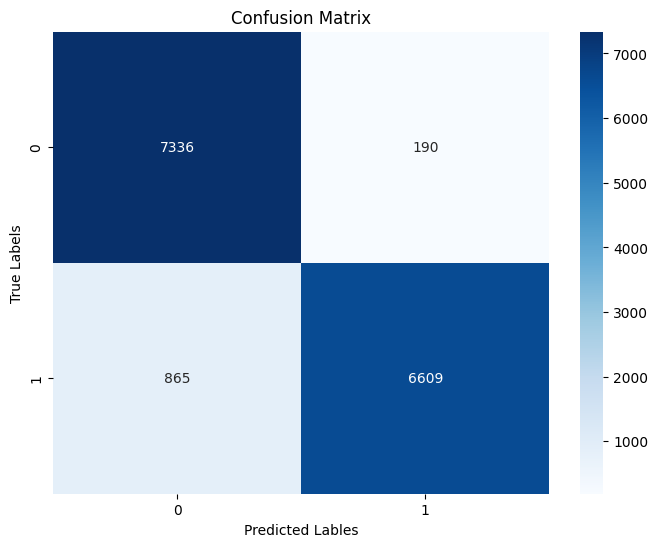

In [44]:
cm = confusion_matrix(Y_test,predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=np.unique(Y),yticklabels=np.unique(Y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Lables")
plt.ylabel("True Labels")
plt.show()


Classification Report:
              precision    recall  f1-score       support
0              0.894525  0.974754  0.932918   7526.000000
1              0.972055  0.884265  0.926084   7474.000000
accuracy       0.929667  0.929667  0.929667      0.929667
macro avg      0.933290  0.929510  0.929501  15000.000000
weighted avg   0.933156  0.929667  0.929513  15000.000000


C:\Users\Usman Mallana\AppData\Local\Temp\ipykernel_5128\816028474.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index[:-3],y=report_df["f1-score"][:-3],palette="viridis")


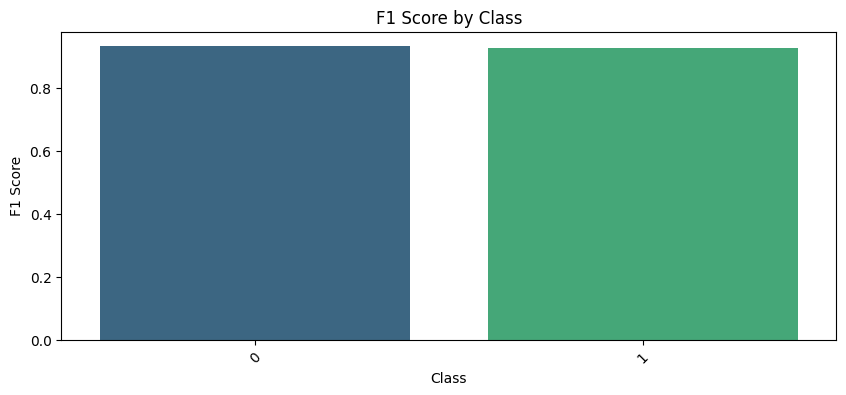

In [47]:
report = classification_report(Y_test,predictions,output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:")
print(report_df)

plt.figure(figsize=(10,4))
sns.barplot(x=report_df.index[:-3],y=report_df["f1-score"][:-3],palette="viridis")
plt.title("F1 Score by Class")
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()